In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Chargement des données
xl = pd.read_excel('MAP_update 2025-2026.xlsm', 
                   sheet_name='data', 
                   header=None, 
                   engine='openpyxl')

# Extraction des 7 premières colonnes
df = xl.iloc[1:, [0,1,2,3,4,5,6]].copy()
df.columns = ['date','taux_long','taux_court','PI','RI','PE','MV']

# Conversion des dates
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# Conversion en numérique
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(df.head(10))
print("\nShape:", df.shape)

            taux_long  taux_court     PI      RI   PE      MV
date                                                         
1980-01-01        NaN     14.5625  82.17  109.86  7.5  603731
1980-02-01        NaN     14.2500  86.44  116.13  7.9  635396
1980-03-01        NaN     17.1250  83.17  112.24  7.6  612505
1980-04-01        NaN     20.2500  76.96  104.37  6.9  567565
1980-05-01        NaN     13.8750  79.92  108.96  7.1  590373
1980-06-01        NaN     10.3125  83.76  114.75  7.5  621492
1980-07-01        NaN      9.8750  86.13  118.53  7.7  639253
1980-08-01        NaN     10.6250  91.16  126.04  8.2  677414
1980-09-01        NaN     12.0625  91.38  126.89  8.2  679655
1980-10-01        NaN     13.2500  93.13  129.89  8.3  694824

Shape: (552, 6)


In [ ]:
# Prime de risque implicite (FED Model)

# Bénéfices implicites E = PI / PE
df['E'] = df['PI'] / df['PE']

# Taux de croissance annuel des bénéfices (glissement annuel en %)
df['g_E'] = df['E'].pct_change(12) * 100

# g_trend = moyenne de g_E sur 1980-2001
g_trend = df.loc['1980':'2001', 'g_E'].mean()
print(f"g_trend (1980-2001) = {g_trend:.4f}%")

# Earnings Yield = 1/PE * 100
df['EY'] = (1 / df['PE']) * 100

# Prime de risque avec taux court
df['ERP_court'] = df['EY'] + g_trend - df['taux_court']

# Prime de risque avec taux long (vide si taux long manquant)
df['ERP_long'] = np.where(df['taux_long'].isna(), 
                          np.nan, 
                          df['EY'] + g_trend - df['taux_long'])

# Moyenne et écart-type de référence
mu_court    = df.loc['1980':'2001', 'ERP_court'].mean()
sigma_court = df.loc['1980':'2001', 'ERP_court'].std()
mu_long     = df.loc['1983':'2001', 'ERP_long'].mean()
sigma_long  = df.loc['1983':'2001', 'ERP_long'].std()

print(f"\nERP taux court (1980-2001):")
print(f"  Moyenne = {mu_court:.4f}%")
print(f"  Ecart-type = {sigma_court:.4f}%")

print(f"\nERP taux long (1983-2001):")
print(f"  Moyenne = {mu_long:.4f}%")
print(f"  Ecart-type = {sigma_long:.4f}%")

g_trend (1980-2001) = 7.1493%

ERP taux court (1980-2001):
  Moyenne = 6.5128%
  Ecart-type = 1.7391%

ERP taux long (1983-2001):
  Moyenne = 5.6688%
  Ecart-type = 0.7700%


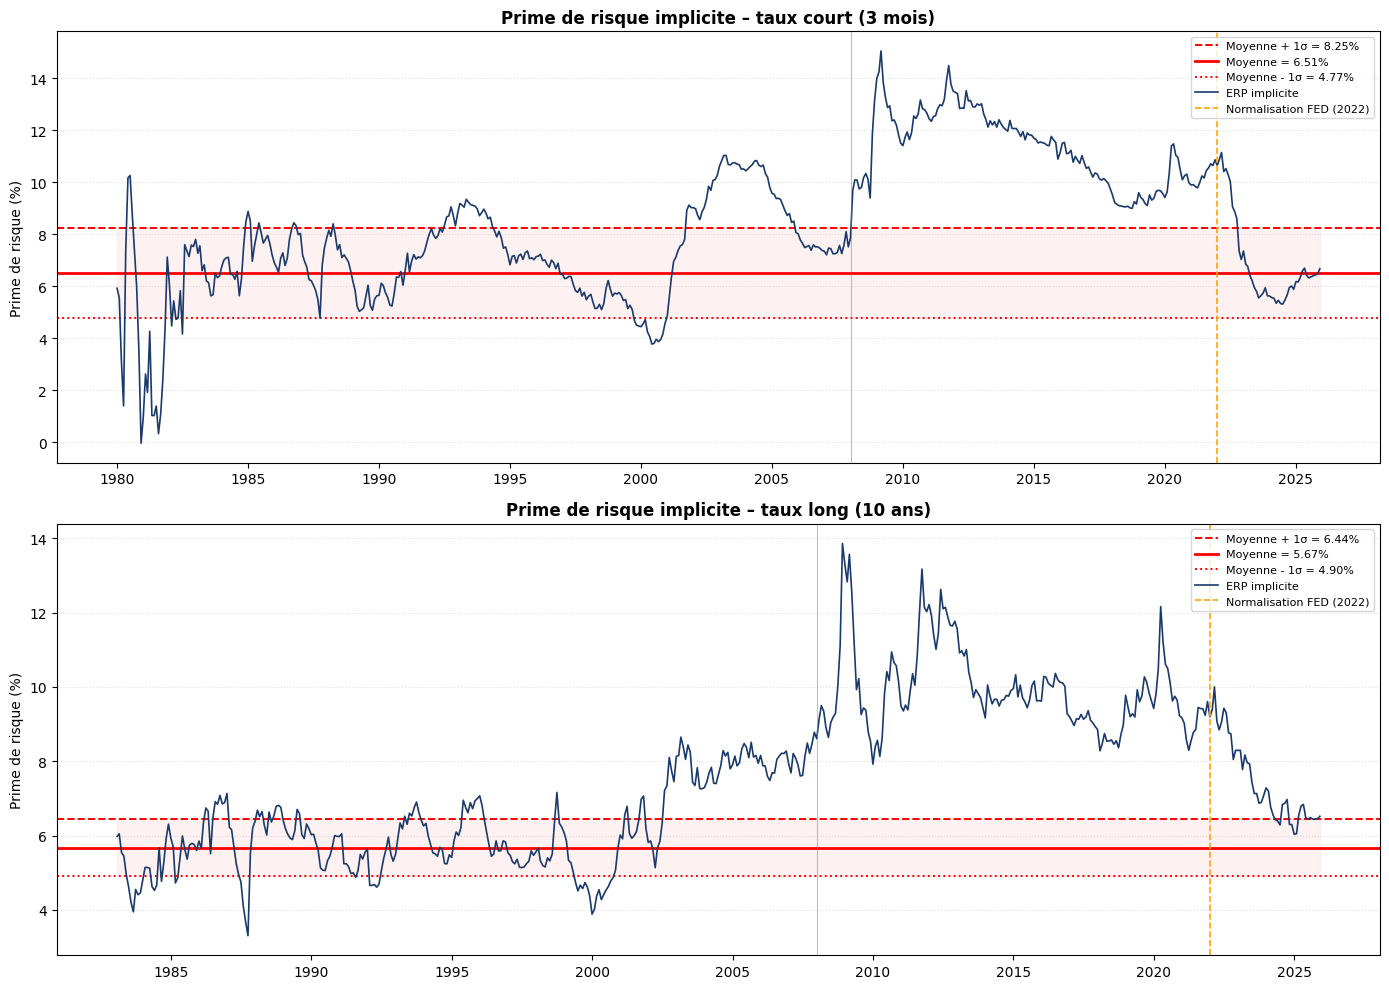

Graphique étape


In [ ]:
# GRAPHIQUE

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, (erp_col, mu, sigma, titre, start) in zip(axes, [
    ('ERP_court', mu_court, sigma_court,
     "Prime de risque implicite – taux court (3 mois)", '1980'),
    ('ERP_long', mu_long, sigma_long,
     "Prime de risque implicite – taux long (10 ans)", '1983'),
]):
    d = df.loc[start:, erp_col].dropna()

    # Zone ± 1 sigma
    ax.fill_between(d.index, mu-sigma, mu+sigma,
                    color='#fde8e8', alpha=0.6)

    # Lignes horizontales
    ax.axhline(mu+sigma, color='red', lw=1.4, ls='--',
               label=f'Moyenne + 1σ = {mu+sigma:.2f}%')
    ax.axhline(mu, color='red', lw=2, ls='-',
               label=f'Moyenne = {mu:.2f}%')
    ax.axhline(mu-sigma, color='red', lw=1.4, ls=':',
               label=f'Moyenne - 1σ = {mu-sigma:.2f}%')

    # Courbe ERP
    ax.plot(d.index, d.values, color='#1a3a6b',
            lw=1.2, label='ERP implicite')

    # Séparateurs
    ax.axvline(pd.Timestamp('2008-01-01'),
               color='gray', lw=0.8, alpha=0.5)
    ax.axvline(pd.Timestamp('2022-01-01'),
               color='orange', lw=1.2, ls='--',
               label='Normalisation FED (2022)')

    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.set_ylabel('Prime de risque (%)')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', ls=':', alpha=0.4)

plt.tight_layout()
plt.savefig('etape1_ERP.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique étape")

1983–2001 (période de référence) :
La prime oscille autour de sa moyenne (5,67%) dans une bande étroite ±0,77%. Le DDM est pertinent : le marché valorise correctement les actions en fonction des taux et des bénéfices.2002–2007 :
La prime commence à monter au-dessus de la moyenne. Le modèle devient moins précis.2008–2021 :
La prime explose au-dessus de μ + 1σ de façon permanente. Les taux maintenus artificiellement bas par la FED faussent le calcul — le modèle signale une sous-évaluation qui n'est pas réelle.2022–2025 :
La normalisation des taux ramène la prime vers sa moyenne. Le DDM retrouve de sa pertinence.

In [ ]:
# Régressions log(Prix) ~ taux_long + log(E)

import statsmodels.api as sm

# Variables
df['log_PI'] = np.log(df['PI'])
df['log_E']  = np.log(df['E'])

# Sous-périodes
sub1 = df.loc['1983':'2007'].dropna(subset=['log_PI','taux_long','log_E'])
sub2 = df.loc['2008':'2025'].dropna(subset=['log_PI','taux_long','log_E'])

def regression(sub, label):
    X = sm.add_constant(sub[['taux_long','log_E']])
    y = sub['log_PI']
    res = sm.OLS(y, X).fit()
    print(f"\n--- Régression {label} ---")
    print(f"  R²        = {res.rsquared:.4f}")
    print(f"  Constante = {res.params['const']:.4f} (t={res.tvalues['const']:.2f})")
    print(f"  taux_long = {res.params['taux_long']:.4f} (t={res.tvalues['taux_long']:.2f})")
    print(f"  log(E)    = {res.params['log_E']:.4f} (t={res.tvalues['log_E']:.2f})")
    print(f"  Sensibilite +100bp -> {res.params['taux_long']*100:.2f}%")
    print(f"  Elasticite Prix/Benefices = {res.params['log_E']:.4f}")
    return res

res1 = regression(sub1, "1983-2007")
res2 = regression(sub2, "2008-2025")


--- Régression 1983-2007 ---
  R²        = 0.9516
  Constante = 3.5664 (t=21.71)
  taux_long = -0.1038 (t=-12.38)
  log(E)    = 1.0076 (t=29.72)
  Sensibilite +100bp -> -10.38%
  Elasticite Prix/Benefices = 1.0076

--- Régression 2008-2025 ---
  R²        = 0.9004
  Constante = 1.1056 (t=7.29)
  taux_long = -0.0322 (t=-2.72)
  log(E)    = 1.4308 (t=43.40)
  Sensibilite +100bp -> -3.22%
  Elasticite Prix/Benefices = 1.4308


Sensibilité taux long : −10,38% → −3,22% (3× plus faible après 2008) 
Élasticité bénéfices : 1,008 → 1,431 (marché valorise plus les bénéfices)
La sensibilité des prix au taux long est 3× plus faible après 2008 (−0,032 vs −0,104). Cela confirme que le marché s'est découplé des taux après la crise. En revanche l'élasticité aux bénéfices augmente (1,008 → 1,431) : le marché valorise davantage la croissance des bénéfices que les taux.

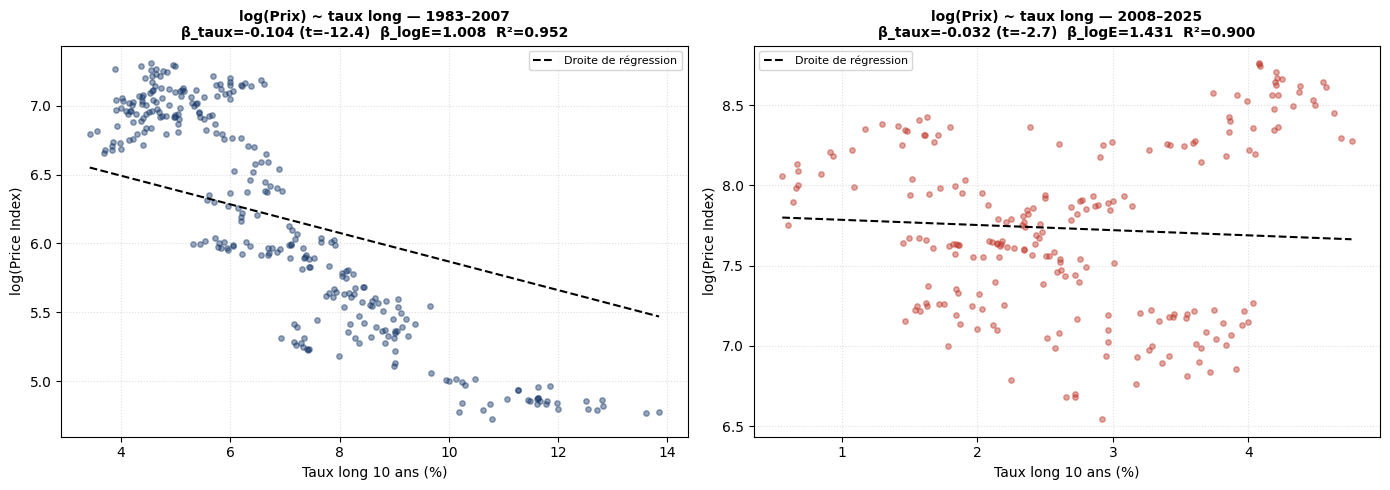

Graphique étape 2 sauvegarde !


In [ ]:
# GRAPHIQUE 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, sub, res, label, col in zip(axes,
    [sub1, sub2],
    [res1, res2],
    ['1983–2007', '2008–2025'],
    ['#1a3a6b', '#c0392b']
):
    ax.scatter(sub['taux_long'], sub['log_PI'], 
               alpha=0.45, s=15, color=col)
    
    # Droite de régression
    x_range = np.linspace(sub['taux_long'].min(), 
                          sub['taux_long'].max(), 100)
    y_pred = (res.params['const'] + 
              res.params['taux_long'] * x_range + 
              res.params['log_E'] * sub['log_E'].mean())
    ax.plot(x_range, y_pred, 'k--', lw=1.5, 
            label='Droite de régression')
    
    ax.set_title(
        f"log(Prix) ~ taux long — {label}\n"
        f"β_taux={res.params['taux_long']:.3f} "
        f"(t={res.tvalues['taux_long']:.1f})  "
        f"β_logE={res.params['log_E']:.3f}  "
        f"R²={res.rsquared:.3f}",
        fontsize=10, fontweight='bold')
    ax.set_xlabel('Taux long 10 ans (%)')
    ax.set_ylabel('log(Price Index)')
    ax.legend(fontsize=8)
    ax.grid(ls=':', alpha=0.4)

plt.tight_layout()
plt.savefig('etape2_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique étape 2 sauvegarde !")


--- Taux long d'équilibre r* ---
r* moyen 2008-2021: 6.63%
Taux obs. moyen 2008-2021: 2.36%
r* moyen 2022-2025: 5.56%
Taux obs. moyen 2022-2025: 3.79%
r* decembre 2025: 4.93%
Taux obs. decembre 2025: 4.08%


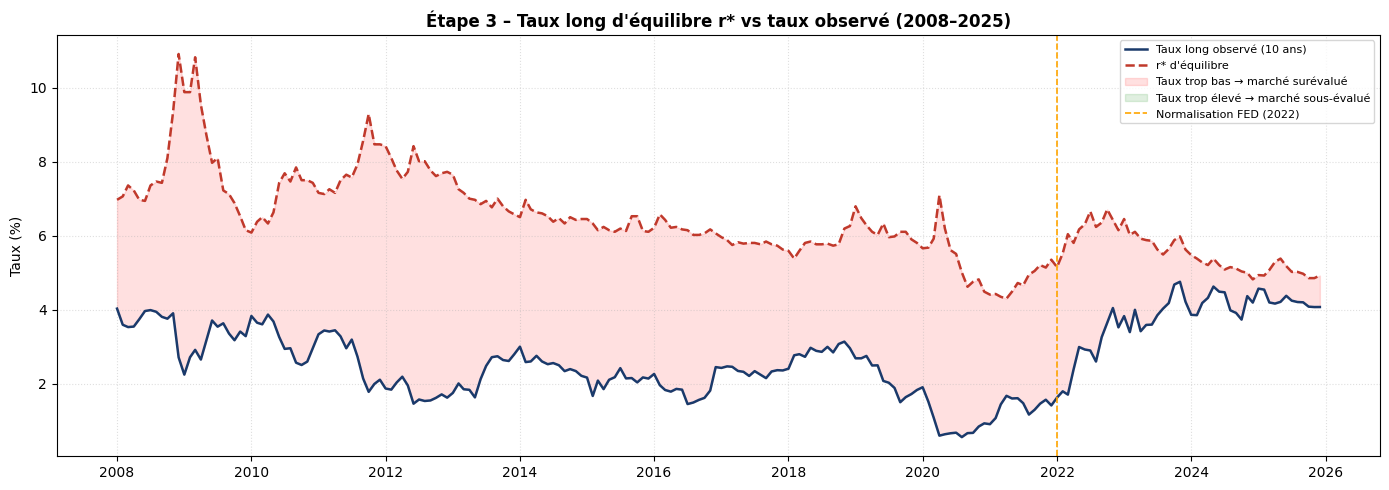

Graphique étape 3 sauvegarde !


In [ ]:
# Taux long d'équilibre r* #

# r* = EY + g_trend - mu_long
# Calculé uniquement à partir de 2008
df['r_star'] = np.where(
    df.index >= pd.Timestamp('2008-01-01'),
    df['EY'] + g_trend - mu_long,
    np.nan
)

# Statistiques
print("\n--- Taux long d'équilibre r* ---")
print(f"r* moyen 2008-2021: {df.loc['2008':'2021','r_star'].mean():.2f}%")
print(f"Taux obs. moyen 2008-2021: {df.loc['2008':'2021','taux_long'].mean():.2f}%")
print(f"r* moyen 2022-2025: {df.loc['2022':'2025','r_star'].mean():.2f}%")
print(f"Taux obs. moyen 2022-2025: {df.loc['2022':'2025','taux_long'].mean():.2f}%")
print(f"r* decembre 2025: {df['r_star'].iloc[-1]:.2f}%")
print(f"Taux obs. decembre 2025: {df['taux_long'].iloc[-1]:.2f}%")

# GRAPHIQUE

d3 = df.loc['2008':].dropna(subset=['taux_long','r_star'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(d3.index, d3['taux_long'], color='#1a3a6b', 
        lw=1.8, label='Taux long observé (10 ans)')
ax.plot(d3.index, d3['r_star'], color='#c0392b', 
        lw=1.8, ls='--', label="r* d'équilibre")

ax.fill_between(d3.index, d3['taux_long'], d3['r_star'],
                where=d3['r_star'] > d3['taux_long'], 
                alpha=0.12, color='red',
                label='Taux trop bas → marché surévalué')
ax.fill_between(d3.index, d3['taux_long'], d3['r_star'],
                where=d3['r_star'] < d3['taux_long'], 
                alpha=0.12, color='green',
                label='Taux trop élevé → marché sous-évalué')

ax.axvline(pd.Timestamp('2022-01-01'), color='orange', 
           lw=1.2, ls='--', label='Normalisation FED (2022)')

ax.set_title("Étape 3 – Taux long d'équilibre r* vs taux observé (2008–2025)",
             fontsize=12, fontweight='bold')
ax.set_ylabel('Taux (%)')
ax.legend(fontsize=8)
ax.grid(ls=':', alpha=0.4)

plt.tight_layout()
plt.savefig('etape3_r_star.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique étape 3 sauvegarde !")

Le graphique montre exactement ce qu'on attend :
2008–2021 :

r* moyen = 6,63% vs taux observé = 2,36%
Écart de plus de 4 points → zone rouge → taux artificiellement bas 

2022–2025 :
Les deux courbes convergent → normalisation FED 
Écart en décembre 2025 = seulement 0,85 point (4,93% vs 4,08%) 

Le profil de r* confirme l'hypothèse de départ — les taux observés étaient bien artificiels et temporaires sur 2008–2021. La normalisation post-2022 rapproche les deux courbes, ce qui suggère un retour à la pertinence du DDM.

In [ ]:
# Aversion au risque Arrow-Pratt

# Rendement annuel du Return Index (glissement annuel en %)
df['ret_annual'] = df['RI'].pct_change(12) * 100

# Variance sur 1983-2001
var_83_01 = df.loc['1983':'2001', 'ret_annual'].dropna().var()

# Variance sur 2008-2025
var_08_25 = df.loc['2008':'2025', 'ret_annual'].dropna().var()

# Aversion au risque A = mu_long / var_83_01
A = mu_long / var_83_01

# Prime de risque Arrow-Pratt 2008-2025
ERP_AP = A * var_08_25

print("\n--- Étape 4 : Arrow-Pratt ---")
print(f"Variance rendement 1983-2001 : {var_83_01:.2f} %²")
print(f"Moyenne ERP long 1983-2001   : {mu_long:.4f}%")
print(f"Aversion au risque A         : {A:.6f}")
print(f"Variance rendement 2008-2025 : {var_08_25:.2f} %²")
print(f"ERP Arrow-Pratt 2008-2025    : {ERP_AP:.4f}%")


--- Étape 4 : Arrow-Pratt ---
Variance rendement 1983-2001 : 257.48 %²
Moyenne ERP long 1983-2001   : 5.6688%
Aversion au risque A         : 0.022017
Variance rendement 2008-2025 : 303.39 %²
ERP Arrow-Pratt 2008-2025    : 6.6797%


L'aversion au risque A = 0,022 est stable dans le temps. La variance du marché est plus élevée après 2008 (303 vs 257 %²), ce qui justifie une prime de risque plus élevée. La prime Arrow-Pratt 2008–2025 = 6,68% contre 5,67% en référence.


--- Étape 5 : Diagnostic final ---
Sigma ERP long 1983-2007 : 1.1685%
Sigma ERP long 2008-2025 : 1.5410%
Nouvelle moyenne (AP)    : 6.6797%
Bande haute 2008-2025    : 8.2207%
Bande basse 2008-2025    : 5.1387%

ERP observée déc. 2025   : 6.5197%
DIAGNOSTIC               : JUSTE VALORISATION ✓


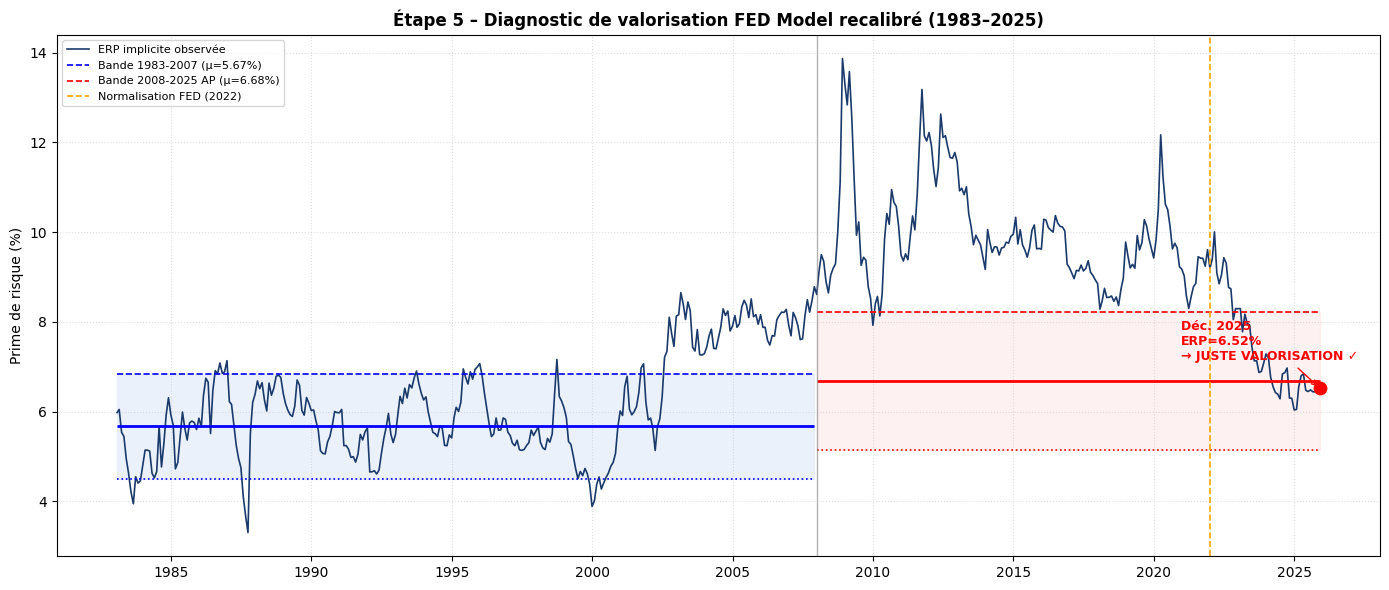

Graphique étape 5 sauvegarde !


In [ ]:
# Diagnostic final (FED Model recalibré)

# Écart-types ERP long sur les deux périodes
sigma_83_07 = df.loc['1983':'2007', 'ERP_long'].dropna().std()
sigma_08_25 = df.loc['2008':'2025', 'ERP_long'].dropna().std()

print("\n--- Étape 5 : Diagnostic final ---")
print(f"Sigma ERP long 1983-2007 : {sigma_83_07:.4f}%")
print(f"Sigma ERP long 2008-2025 : {sigma_08_25:.4f}%")
print(f"Nouvelle moyenne (AP)    : {ERP_AP:.4f}%")
print(f"Bande haute 2008-2025    : {ERP_AP+sigma_08_25:.4f}%")
print(f"Bande basse 2008-2025    : {ERP_AP-sigma_08_25:.4f}%")

# ERP décembre 2025
erp_dec25 = df['ERP_long'].iloc[-1]
print(f"\nERP observée déc. 2025   : {erp_dec25:.4f}%")

# Diagnostic
if erp_dec25 < ERP_AP - sigma_08_25:
    verdict = "SURÉVALUÉ ✗"
elif erp_dec25 > ERP_AP + sigma_08_25:
    verdict = "SOUS-ÉVALUÉ"
else:
    verdict = "JUSTE VALORISATION ✓"
print(f"DIAGNOSTIC               : {verdict}")

# GRAPHIQUE ÉTAPE 5
d_full = df.loc['1983':].dropna(subset=['ERP_long'])
d_pre  = d_full.loc[:'2007']
d_post = d_full.loc['2008':]

fig, ax = plt.subplots(figsize=(14, 6))

# Courbe ERP
ax.plot(d_full.index, d_full['ERP_long'], 
        color='#1a3a6b', lw=1.2, label='ERP implicite observée')

# Bande avant 2008
ax.fill_between(d_pre.index, 
                mu_long-sigma_83_07, mu_long+sigma_83_07,
                color='#dce8f8', alpha=0.6)
ax.hlines([mu_long+sigma_83_07, mu_long, mu_long-sigma_83_07],
          d_pre.index[0], d_pre.index[-1],
          colors=['blue','blue','blue'],
          linewidths=[1.2, 2, 1.2],
          linestyles=['--','-',':'],
          label=f'Bande 1983-2007 (μ={mu_long:.2f}%)')

# Bande après 2008
ax.fill_between(d_post.index,
                ERP_AP-sigma_08_25, ERP_AP+sigma_08_25,
                color='#fde8e8', alpha=0.6)
ax.hlines([ERP_AP+sigma_08_25, ERP_AP, ERP_AP-sigma_08_25],
          d_post.index[0], d_post.index[-1],
          colors=['red','red','red'],
          linewidths=[1.2, 2, 1.2],
          linestyles=['--','-',':'],
          label=f'Bande 2008-2025 AP (μ={ERP_AP:.2f}%)')

# Séparateur 2008
ax.axvline(pd.Timestamp('2008-01-01'), 
           color='gray', lw=1, alpha=0.6)
ax.axvline(pd.Timestamp('2022-01-01'),
           color='orange', lw=1.2, ls='--',
           label='Normalisation FED (2022)')

# Point diagnostic final
ax.scatter([d_full.index[-1]], [erp_dec25], 
           color='red', zorder=5, s=80)
ax.annotate(f'Déc. 2025\nERP={erp_dec25:.2f}%\n→ {verdict}',
            xy=(d_full.index[-1], erp_dec25),
            xytext=(-100, 20), textcoords='offset points',
            fontsize=9, color='red', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_title("Étape 5 – Diagnostic de valorisation FED Model recalibré (1983–2025)",
             fontsize=12, fontweight='bold')
ax.set_ylabel('Prime de risque (%)')
ax.legend(fontsize=8, loc='upper left')
ax.grid(ls=':', alpha=0.4)

plt.tight_layout()
plt.savefig('etape5_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique étape 5 sauvegarde !")

Avec la prime recalibrée selon Arrow-Pratt, le marché américain est à juste valorisation en décembre 2025. L'ERP observée (6,52%) est légèrement en dessous de la nouvelle moyenne (6,68%) mais bien dans la bande de confiance [5,14% ; 8,22%].
Ce résultat est important car avec l'ancienne référence de l'étape 1 (μ=5,67%), le marché aurait semblé surévalué — l'ERP de 6,52% étant bien au-dessus de μ+σ=6,44%. La recalibration Arrow-Pratt corrige ce biais.